# Coding a Neural Net from scratch using numpy and math
### Architecture
- Input layer of 784
- First Hidden Layer of 128 neurons with ReLU
- Second Hidden Layer of 128 neurons with ReLU
- Outputs layer with softmax

In [1]:
import pandas as pd
import numpy as np

## Basics of the net

I will use the MNIST dataset to train the NN model.

In [2]:
# Extract the explanatory variable and target variables, scale them and put them in numpy array
df = pd.read_csv("/Users/homelab/Desktop/deep_learning/mnist_cleaner/archive/mnist_train.csv")
X = (df.drop(columns=["label"]) /255).values
y = df["label"].values

print(X.shape)

(60000, 784)


In [3]:
# Convert the output variable into probability distribution of each number. One hot encode it.
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

Y = one_hot_encode(y,10)

print(Y.shape)

(60000, 10)


## Input layer

In [23]:
input_layer = X[0:1]

In [24]:
input_layer.shape

(1, 784)

# Forward Pass with single instance

## First hidden layer

### 1. Initializing random weights and biases

In [25]:
number_of_neurons = 128
np.random.seed(11)

# first hidden layer weights
W1 = np.random.randn(X.shape[1], number_of_neurons)

# first hidden layer biases
b1 = np.random.randn(1, number_of_neurons)

### 2. Pre-activation values and outputs

In [26]:
# pre-activation values
Z1 = np.dot(input_layer, W1) + b1

# activation function -> ReLU
def relu(z):
    return np.maximum(0, z)

# output values of the first hidden layer
A1 = relu(Z1)
print(A1.shape)

(1, 128)


## Second hidden layer

In [27]:
# second hidden layer weights
W2 = np.random.randn(A1.shape[1], number_of_neurons)

# second hidden layer biases
b2 = np.random.randn(1, number_of_neurons)

# pre-activation values
Z2 = np.dot(A1, W2) + b2

# output of hidden layer 2
A2 = relu(Z2)
print(A2.shape)

(1, 128)


## Output layer

In [28]:
output_layer_n = 10

W3 = np.random.randn(A2.shape[1], output_layer_n)
b3 = np.random.randn(1, output_layer_n)
Z3 = np.dot(A2, W3) + b3

In [29]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return (exp_z / np.sum(exp_z, axis=-1, keepdims=True))


output_neurons = softmax(Z3)
output_neurons

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.58436095e-13]])

# Forward Pass with a batch

The problem with the code above is that it only takes a single instance as input and it only produces a single row of output probabilities. I could solve this by using a loop all over the training set but it is quite slow or using all of the training instances at one go but it may not fit into the memory. Using batches allows us to:
- train faster, by implementing parralell computing
- acts as a reguralizator, avoids overfitting
- fits into memory

It is fairly simple to move from one instance to processing batches. Just slice n-sized batches off the training set. 

But first lets define the loss function, which measures how the model performs on the batches. For this I will use the categorical cross entropy loss function, so lets create that.

### Loss function

In [30]:
def categorical_cross_entropy(y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.sum(y_true * np.log(y_pred_clipped)) / y_true.shape[0]

### Feed Forward Part

In [31]:
# INITIAL SETTINGS
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = np.random.randn(X.shape[1], number_of_neurons)
b1 = np.random.randn(1, number_of_neurons)

# 2nd hidden layer
W2 = np.random.randn(A1.shape[1], number_of_neurons)
b2 = np.random.randn(1, number_of_neurons)

# output layer
output_layer_neurons = 10
W3 = np.random.randn(A2.shape[1], output_layer_neurons)
b3 = np.random.randn(1, output_layer_neurons)

for i in range(0, num_sample, batch_size):
    X_batch = X[i: i + batch_size]
    Y_batch = Y[i: i + batch_size]

    # FIRST HIDDEN LAYER
    Z1 = X_batch @ W1 + b1
    A1 = relu(Z1)

    # SECOND HIDDEN LAYER
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    # OUTPUT LAYER
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    # LOSS FUNCTION
    loss = categorical_cross_entropy(Y_batch, A3)
    

So the model above represent the forward pass with batch size 128. The model has:
- input layer of 784 neurons 
- first hidden layer with 128 neurons, 784x128 weights with normal distribution initialization and 128 biases with ReLU
- second hidden layer with 128 neurons, 128x128 weights with normal distribution initialization and 128 biases with ReLU
- output layer with 10 neurons, 128x10 weights with normal distributioin initialization and 10 biases with softmax activation
- categorical cross entropy loss function

However one thing might mess up the whole algorithm. Vanishing or exploading gradients. The weight and bias initialization are drawn from Gaussian distribution but depending on the size of the layer the variances could explode or vanish. That is why we need to use He initialization by scaling these randomly drawn numbers.

Also since I broke the symetry of the layers by randomly sampling the weights from gaussian distribution, I do not need to randomly sample values for biases, just set them to 0.

### Proving variance difference between layers

In [32]:
num_sampless = 10000

for N in [10, 100, 1000]:
    Xx = np.random.randn(num_sampless, N)
    Ww = np.random.randn(N, 1)
    Zz = Xx @ Ww  

    print(f"Layer width N = {N}  -> Variance = {np.var(Zz):.2f}")

Layer width N = 10  -> Variance = 5.16
Layer width N = 100  -> Variance = 88.64
Layer width N = 1000  -> Variance = 961.86


### Adding He initialization to avoid exploading/vanishing gradients

In [33]:
# INITIAL SETTINGS
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1])
b1 = np.zeros((1, number_of_neurons))

# 2nd hidden layer
W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons)
b2 = np.zeros((1, number_of_neurons))

# output layer
output_layer_neurons = 10
W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons)
b3 = np.zeros((1, output_layer_neurons))

for i in range(0, num_sample, batch_size):
    X_batch = X[i: i + batch_size]
    Y_batch = Y[i: i + batch_size]

    # FIRST HIDDEN LAYER
    Z1 = X_batch @ W1 + b1
    A1 = relu(Z1)

    # SECOND HIDDEN LAYER
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    # OUTPUT LAYER
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    # LOSS FUNCTION
    loss = categorical_cross_entropy(Y_batch, A3)
    

Up until now we have a perfectly running feed forward net. It takes input processes it, generates an output and the other layer processes it. But now comes the exciting part. We need to changes these weights so the model can learn and fit to training instaces. To do this I need to write a the backpropagation part.

# Backpropagation

This process flows backwards. So first, output layer -> 2nd hidden layer -> 1st hidden layer. I need to calculate 3 things per layer.
1. Error at the pre-activation of the layer
2. Gradient wrt. Wi
3. Gradient wrt. bi

### Output layer gradients
When softmax is combined with categorical cross entropy the derivative wrt. Z3 of the loss function simplifies to:
$$dZ_3 = \frac{A_3 - Y_{\text{batch}}}{m}$$

where:
- A3 predicted probabilities from softmax
- Y_batch, the true labes in the batch
- m, batch size

In [200]:
#  Differentiation of the loss function wrt. Z3 -> pre-activation values
m = Y_batch.shape[0]
dZ3 = A3 - Y_batch / m

To calculate how much W3 contribute to the total loss, I need to differentiate the loss function wrt. W3. To get the derivative dW3 I multiply the coming signal from previous layer A2, with the error of the current layer dZ3
$$\frac{\partial \mathcal{L}}{\partial W_3} = A_2^T \cdot dZ_3$$

In [201]:
#  Differentiation of the loss function wrt. W3 -> weights of output layer
dW3 = A2.T @ dZ3

Since the bias vector is shared across all m example in the batch, its gradient is simply the sum of dZ3 across all the rows in the batch.

In [202]:
db3 = np.sum(dZ3, axis=0, keepdims=True)

### Output layer backpropagation

In [203]:
m = Y_batch.shape[0]

dZ3 = (A3 - Y_batch) / m
dW3 = A2.T @ dZ3
db3 = np.sum(dZ3, axis=0, keepdims=True)

### 2nd hidden layer backpropagation

Calculate dZ2, which is the error entering layer 2. To calculate this, use dZ3 and multiply it by W3.T and multiply it by the derivative of ReLu for Z2.
$$dZ_2 = (dZ_3 \cdot W_3^T) \odot \text{ReLU}'(Z_2)$$

In [204]:
def relu_derivative(z):
    return (z > 0).astype(float)

dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
dW2 = A1.T @ dZ2                            # same as the previous layer
db2 = np.sum(dZ2, axis=0, keepdims=True)    # same as the previous layer

### 1st hidden layer backpropagation

To calculate dZ1, which is the error entering layer 1, use dZ2 and multiply it by W2.T and multiply it by the derivative of ReLU for Z1.
$$dZ_1 = (dZ_2 \cdot W_2^T) \odot \text{ReLU}'(Z_1)$$

In [205]:
dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
dW1 = X_batch.T @ dZ1
db1 = np.sum(dZ1, axis=0, keepdims=True)

Now all the gradients are calculated. I can move on to the updating part of the weights.

# Gradient Descent

Since the gradient points towards the steepest increase of the loss, we subtract a small ratio of the gradient to move lower towards the global minimum of the loss function.
$$\text{New Parameter} = \text{Old Parameter} - (\text{learning\_rate} \times \text{Gradient})$$
$$\begin{aligned} W_3 &= W_3 - \alpha \cdot dW_3 \\ b_3 &= b_3 - \alpha \cdot db_3 \end{aligned}$$

where alpha is the learning rate.

In [206]:
learning_rate = 0.01

# layer 3
W3 -= learning_rate * dW3
b3 -= learning_rate * db3

# layer 2
W2 -= learning_rate * dW2
b2 -= learning_rate * db2

# layer 1
W1 -= learning_rate * dW1
b1 -= learning_rate * db1

# Putting the model together

In [207]:
# INITIAL SETTINGS
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1])
b1 = np.zeros((1, number_of_neurons))

# 2nd hidden layer
W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons)
b2 = np.zeros((1, number_of_neurons))

# output layer
output_layer_neurons = 10
W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons)
b3 = np.zeros((1, output_layer_neurons))

# derivative of relu
def relu_derivative(z):
    return (z > 0).astype(float)

learning_rate = 0.01

w3_list = []
w3_list.append(W3)

for i in range(0, num_sample, batch_size):
    X_batch = X[i: i + batch_size]
    Y_batch = Y[i: i + batch_size]

    # FIRST HIDDEN LAYER
    Z1 = X_batch @ W1 + b1
    A1 = relu(Z1)

    # SECOND HIDDEN LAYER
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    # OUTPUT LAYER
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    # LOSS FUNCTION
    loss = categorical_cross_entropy(Y_batch, A3)

    #### BACKPROPAGATION ####
    # calculating partial derivatives
    # output layer
    m = Y_batch.shape[0]

    dZ3 = (A3 - Y_batch) / m
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # 2nd hidden layer
    dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
    dW2 = A1.T @ dZ2                            
    db2 = np.sum(dZ2, axis=0, keepdims=True)    

    # 1st hidden layer 
    dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
    dW1 = X_batch.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # UPDATING WEIGHTS WITH GRADIENTS #
    # layer 3
    W3 -= learning_rate * dW3
    w3_list.append(W3.copy()) # keeping track of w3 weights
    b3 -= learning_rate * db3

    # layer 2
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # layer 1
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


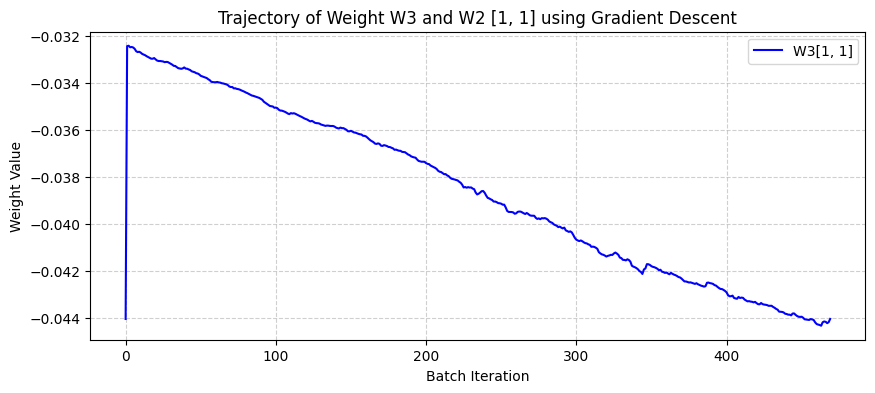

In [208]:
import matplotlib.pyplot as plt
row, col = 1, 1
weight_trajectory = [w[row, col] for w in w3_list]

plt.figure(figsize=(10, 4))
plt.plot(weight_trajectory, color='blue', linewidth=1.5, label=f'W3[{row}, {col}]')

plt.title(f'Trajectory of Weight W3 and W2 [{row}, {col}] using Gradient Descent')
plt.xlabel('Batch Iteration')
plt.ylabel('Weight Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Iterating over multiple epochs

Okay, this works, but only looked at one epoch. I need to iterate it over many epoch until it converges.

In [209]:
# INITIAL SETTINGS
epochs = 10
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1])
b1 = np.zeros((1, number_of_neurons))

# 2nd hidden layer
W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons)
b2 = np.zeros((1, number_of_neurons))

# output layer
output_layer_neurons = 10
W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons)
b3 = np.zeros((1, output_layer_neurons))

# derivative of relu
def relu_derivative(z):
    return (z > 0).astype(float)

learning_rate = 0.01

history_loss = []
history_acc = []
accuracy = 0.0

print("Starting training...\n" + "-"*45)

for epoch in range(epochs):
    
    # SHUFFLE DATA AT START OF EPOCH
    indices = np.arange(num_sample)
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_losses = []
    epoch_accuracies = []

    # MINI BATCH LOOP
    for i in range(0, num_sample, batch_size):

        X_batch = X_shuffled[i: i + batch_size]
        Y_batch = Y_shuffled[i: i + batch_size]

        # FIRST HIDDEN LAYER
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        # SECOND HIDDEN LAYER
        Z2 = A1 @ W2 + b2
        A2 = relu(Z2)

        # OUTPUT LAYER
        Z3 = A2 @ W3 + b3
        A3 = softmax(Z3)

        # LOSS & ACCURACY 
        loss = categorical_cross_entropy(Y_batch, A3)
        preds = A3.argmax(axis=1)
        targets = Y_batch.argmax(axis=1)
        acc = np.mean(preds == targets)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)


        #### BACKPROPAGATION ####
        # calculating partial derivatives
        # output layer
        m = Y_batch.shape[0]

        dZ3 = (A3 - Y_batch) / m
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        # 2nd hidden layer
        dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
        dW2 = A1.T @ dZ2                            
        db2 = np.sum(dZ2, axis=0, keepdims=True)    

        # 1st hidden layer 
        dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
        dW1 = X_batch.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # UPDATING WEIGHTS WITH GRADIENTS #
        # layer 3
        W3 -= learning_rate * dW3
        w3_list.append(W3.copy())
        b3 -= learning_rate * db3

        # layer 2
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        # layer 1
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accuracies)) * 100

    history_loss.append(mean_loss)
    history_acc.append(mean_acc)

    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {mean_loss:.4f} - Accuracy: {mean_acc:.2f}%")

Starting training...
---------------------------------------------


Epoch  1/10 - Loss: 1.0582 - Accuracy: 72.11%
Epoch  2/10 - Loss: 0.4402 - Accuracy: 88.02%
Epoch  3/10 - Loss: 0.3553 - Accuracy: 90.11%
Epoch  4/10 - Loss: 0.3160 - Accuracy: 91.05%
Epoch  5/10 - Loss: 0.2903 - Accuracy: 91.83%
Epoch  6/10 - Loss: 0.2706 - Accuracy: 92.36%
Epoch  7/10 - Loss: 0.2548 - Accuracy: 92.82%
Epoch  8/10 - Loss: 0.2414 - Accuracy: 93.20%
Epoch  9/10 - Loss: 0.2299 - Accuracy: 93.52%
Epoch 10/10 - Loss: 0.2195 - Accuracy: 93.77%


# Using a smarter optimizer

### 1. Momentum optimizer

In [210]:
# Velocity matrices initialized to zeros
# These matricies keep track of the previous gradients to construct EMA.
v_W1 = np.zeros_like(W1)
v_b1 = np.zeros_like(b1)

v_W2 = np.zeros_like(W2)
v_b2 = np.zeros_like(b2)

v_W3 = np.zeros_like(W3)
v_b3 = np.zeros_like(b3)

In [211]:
# INITIAL SETTINGS
epochs = 50
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1]) # he normal initialization
b1 = np.zeros((1, number_of_neurons))

# 2nd hidden layer
W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons) # he normal initialization
b2 = np.zeros((1, number_of_neurons))

# output layer
output_layer_neurons = 10
W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons) # he normal initialization
b3 = np.zeros((1, output_layer_neurons))

# derivative of relu
def relu_derivative(z):
    return (z > 0).astype(float)

learning_rate = 0.01
momentum = 0.95
history_loss = []
history_acc = []
accuracy = 0.0
W3_list = []

print("Starting training...\n" + "-"*45)

for epoch in range(epochs):
    
    # SHUFFLE DATA AT START OF EPOCH
    indices = np.arange(num_sample)
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_losses = []
    epoch_accuracies = []

    # MINI BATCH LOOP
    for i in range(0, num_sample, batch_size):

        X_batch = X_shuffled[i: i + batch_size]
        Y_batch = Y_shuffled[i: i + batch_size]

        # FIRST HIDDEN LAYER
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        # SECOND HIDDEN LAYER
        Z2 = np.dot(A1, W2) + b2
        A2 = relu(Z2)

        # OUTPUT LAYER
        Z3 = np.dot(A2, W3) + b3
        A3 = softmax(Z3)

        # LOSS & ACCURACY
        loss = categorical_cross_entropy(Y_batch, A3)
        preds = A3.argmax(axis=1)
        targets = Y_batch.argmax(axis=1)
        acc = np.mean(preds == targets)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)


        #### BACKPROPAGATION ####
        # calculating partial derivatives
        # output layer
        m = Y_batch.shape[0]

        dZ3 = (A3 - Y_batch) / m
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        # 2nd hidden layer
        dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
        dW2 = A1.T @ dZ2                            
        db2 = np.sum(dZ2, axis=0, keepdims=True)    

        # 1st hidden layer 
        dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
        dW1 = X_batch.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # STEPPING FUNCTIONS
        #  LAYER 3 UPDATES WITH MOMENTUM 
        v_W3 = momentum * v_W3 + learning_rate * dW3
        W3 -= v_W3
        W3_list.append(W3.copy())

        v_b3 = momentum * v_b3 + learning_rate * db3
        b3 -= v_b3

        #  LAYER 2 UPDATES WITH MOMENTUM 
        v_W2 = momentum * v_W2 + learning_rate * dW2
        W2 -= v_W2

        v_b2 = momentum * v_b2 + learning_rate * db2
        b2 -= v_b2

        #  LAYER 1 UPDATES WITH MOMENTUM 
        v_W1 = momentum * v_W1 + learning_rate * dW1
        W1 -= v_W1

        v_b1 = momentum * v_b1 + learning_rate * db1
        b1 -= v_b1

    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accuracies)) * 100

    history_loss.append(mean_loss)
    history_acc.append(mean_acc)

    #print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {mean_loss:.4f} - Accuracy: {mean_acc:.2f}%")

Starting training...
---------------------------------------------


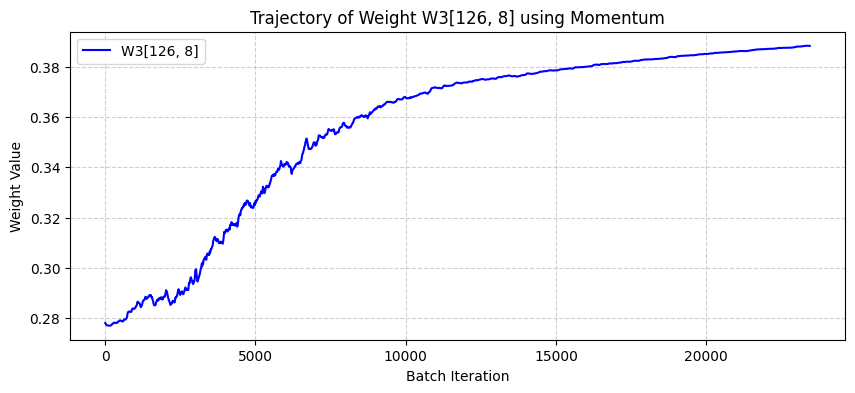

In [212]:
row, col = 126, 8
weight_trajectory = [w[row, col] for w in W3_list]

plt.figure(figsize=(10, 4))
plt.plot(weight_trajectory, color='blue', linewidth=1.5, label=f'W3[{row}, {col}]')

plt.title(f'Trajectory of Weight W3[{row}, {col}] using Momentum')
plt.xlabel('Batch Iteration')
plt.ylabel('Weight Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

It is visible when the epochs are large, the weights tend to converge to a given value. The path is diminishing, later the changes in gradients are smaller and smaller.

### 2. Nesterov Accelerated Gradient NAG

Momentum measures slope where it is currently at, Nesterov measures the slope where the momentum takes the step.
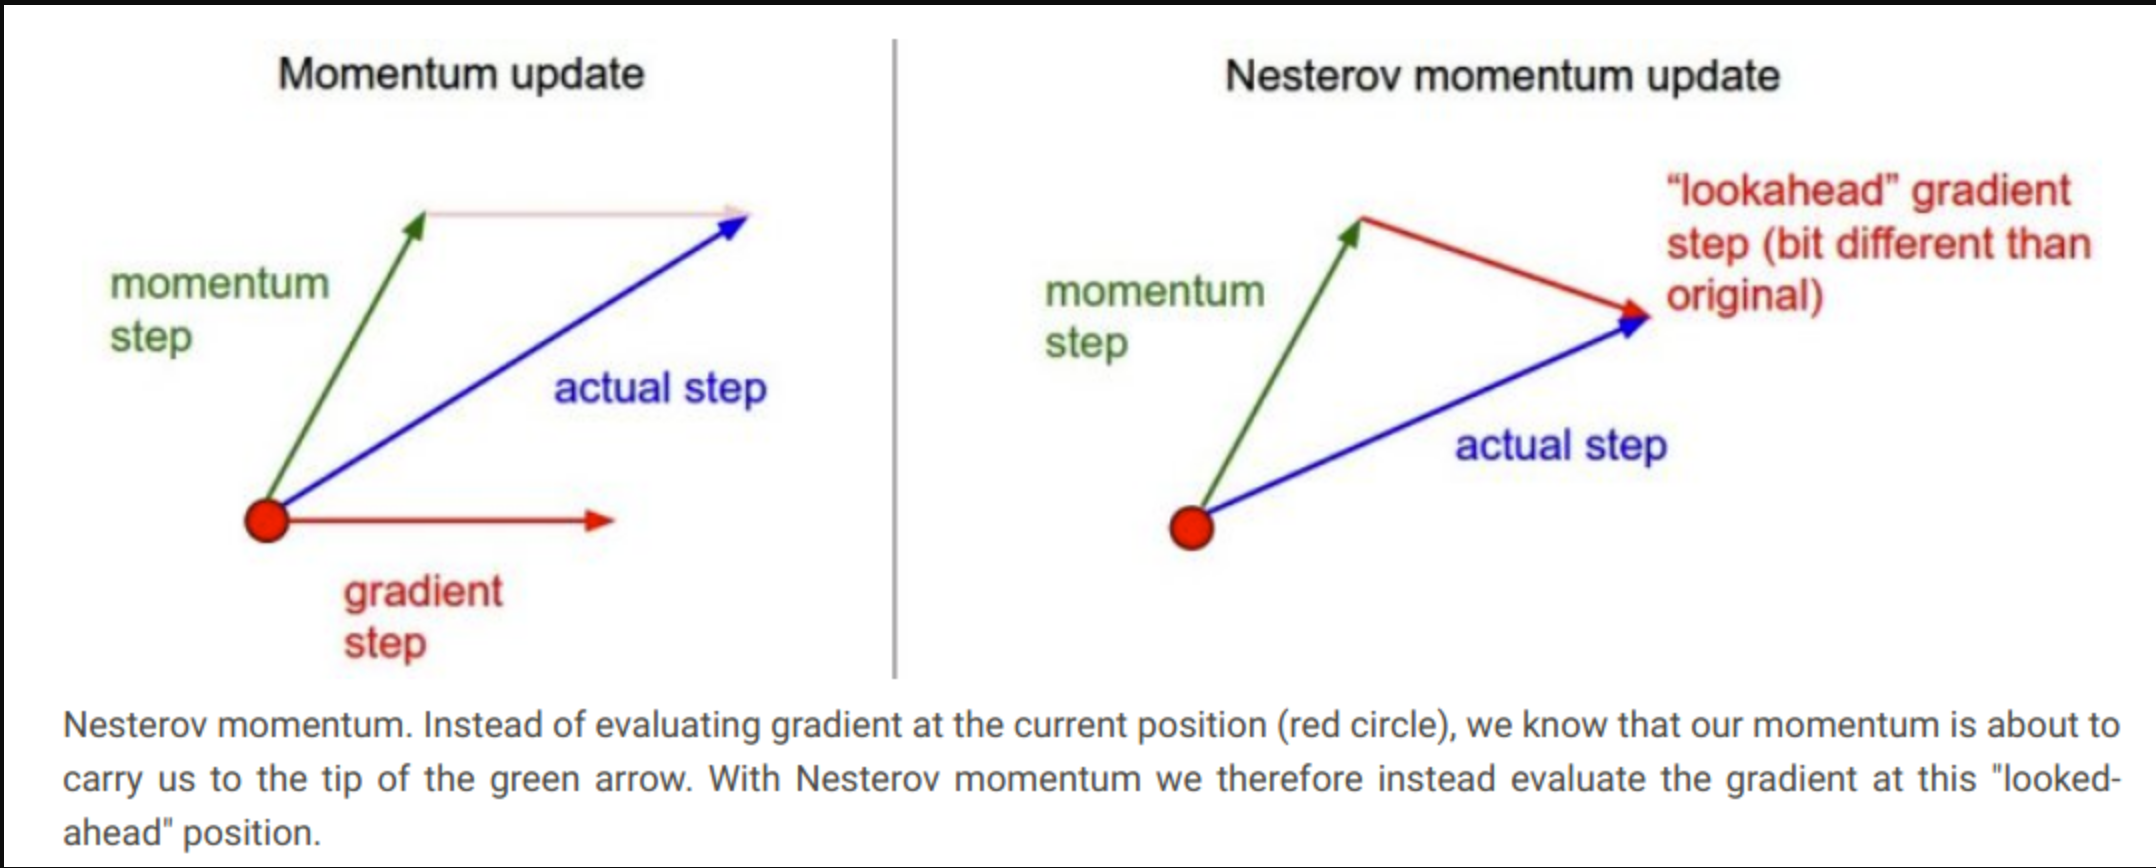

In [213]:
# re-initialize the velocity matrices
v_W1 = np.zeros_like(W1)
v_b1 = np.zeros_like(b1)

v_W2 = np.zeros_like(W2)
v_b2 = np.zeros_like(b2)

v_W3 = np.zeros_like(W3)
v_b3 = np.zeros_like(b3)

In [214]:
# INITIAL SETTINGS
epochs = 50
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1]) # he normal initialization
b1 = np.zeros((1, number_of_neurons))

# 2nd hidden layer
W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons) # he normal initialization
b2 = np.zeros((1, number_of_neurons))

# output layer
output_layer_neurons = 10
W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons) # he normal initialization
b3 = np.zeros((1, output_layer_neurons))

# derivative of relu
def relu_derivative(z):
    return (z > 0).astype(float)

learning_rate = 0.01
momentum = 0.95
history_loss = []
history_acc = []
accuracy = 0.0
W3_list = []

print("Starting training...\n" + "-"*45)

for epoch in range(epochs):
    
    # SHUFFLE DATA AT START OF EPOCH
    indices = np.arange(num_sample)
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_losses = []
    epoch_accuracies = []

    # MINI BATCH LOOP
    for i in range(0, num_sample, batch_size):

        X_batch = X_shuffled[i: i + batch_size]
        Y_batch = Y_shuffled[i: i + batch_size]

        # FIRST HIDDEN LAYER
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        # SECOND HIDDEN LAYER
        Z2 = np.dot(A1, W2) + b2
        A2 = relu(Z2)

        # OUTPUT LAYER
        Z3 = np.dot(A2, W3) + b3
        A3 = softmax(Z3)

        # LOSS & ACCURACY
        loss = categorical_cross_entropy(Y_batch, A3)
        preds = A3.argmax(axis=1)
        targets = Y_batch.argmax(axis=1)
        acc = np.mean(preds == targets)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)


        #### BACKPROPAGATION ####
        # calculating partial derivatives
        # output layer
        m = Y_batch.shape[0]

        dZ3 = (A3 - Y_batch) / m
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        # 2nd hidden layer
        dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
        dW2 = A1.T @ dZ2                            
        db2 = np.sum(dZ2, axis=0, keepdims=True)    

        # 1st hidden layer 
        dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
        dW1 = X_batch.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # STEPPING FUNCTIONS with NAG
        #  LAYER 3 UPDATES WITH MOMENTUM 
        v_W3 = momentum * v_W3 + learning_rate * dW3
        W3 -= momentum * v_W3 + learning_rate * dW3
        W3_list.append(W3.copy())

        v_b3 = momentum * v_b3 + learning_rate * db3
        b3 -= momentum * v_b3 + learning_rate * db3

        #  LAYER 2 UPDATES WITH MOMENTUM 
        v_W2 = momentum * v_W2 + learning_rate * dW2
        W2 -= momentum * v_W2 + learning_rate * dW2

        v_b2 = momentum * v_b2 + learning_rate * db2
        b2 -= momentum * v_b2 + learning_rate * db2

        #  LAYER 1 UPDATES WITH MOMENTUM 
        v_W1 = momentum * v_W1 + learning_rate * dW1
        W1 -= momentum * v_W1 + learning_rate * dW1

        v_b1 = momentum * v_b1 + learning_rate * db1
        b1 -= momentum * v_b1 + learning_rate * db1

    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accuracies)) * 100

    history_loss.append(mean_loss)
    history_acc.append(mean_acc)

    #print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {mean_loss:.4f} - Accuracy: {mean_acc:.2f}%")

Starting training...
---------------------------------------------


So first update the velocity by combining past momentum with the current gradient. Then when updating the weights, subtract both the new velocity and the extra momentum, effectively projecting the parameters one step ahead to brake early if the slope changes.

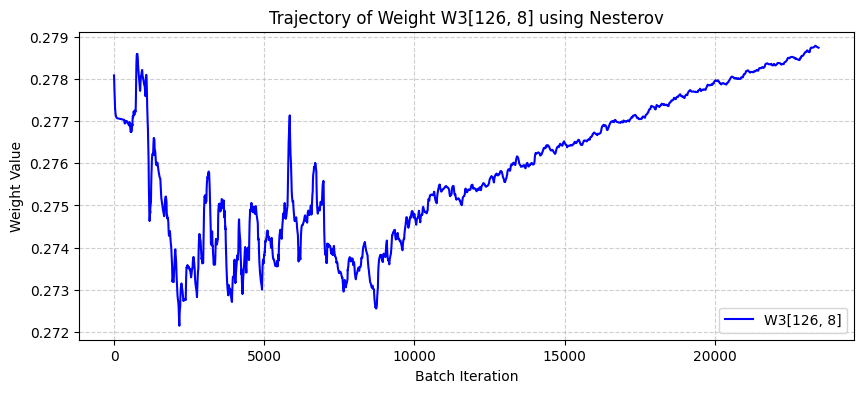

In [215]:
row, col = 126, 8
weight_trajectory = [w[row, col] for w in W3_list]

plt.figure(figsize=(10, 4))
plt.plot(weight_trajectory, color='blue', linewidth=1.5, label=f'W3[{row}, {col}]')

plt.title(f'Trajectory of Weight W3[{row}, {col}] using Nesterov')
plt.xlabel('Batch Iteration')
plt.ylabel('Weight Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### 3. RMSProp

While Momentum and NAG focuses on the direction and speed, RMSProp focues on the scaling of learning rate for each parameter. In NN different weights often have  different gradient scales. Some weights have huge gradients, they oscillate back and forth when the learning rate is too high. Some weight have tiny gradients which does not move even with large learning rates.

Standard SGD and Momentum apply the same global learning rate $\eta$ to every single weight. RMSprop automatically scales the learning rate down for huge-gradient parameters and scales it up for tiny-gradient parameters.

With Nesterov/SGD, one global learning rate has to work for all millions of weights simultaneously. If weight [126, 8] needs a step size of $0.0001$ while weight [12, 4] needs $0.01$, a global $0.01$ will cause [126, 8] to look exactly like your plot.

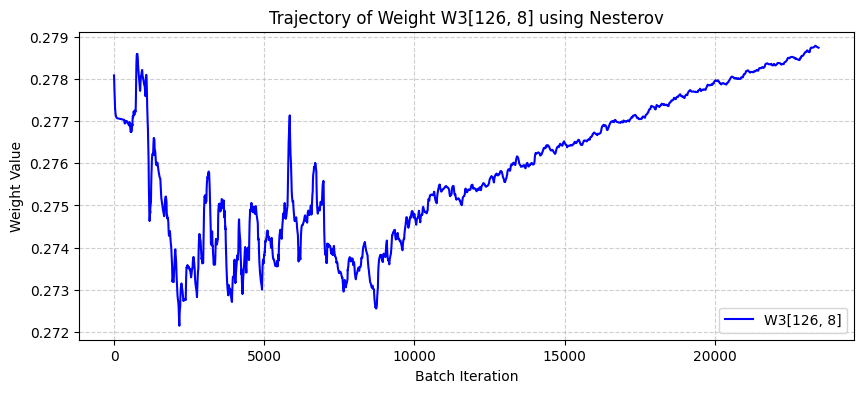

RMSprop gives every single weight its own personalized, adaptive learning rate, smoothing out these wild individual oscillations automatically.

#### How does this work?
The base global learning rate $\eta$ gets divided by the Root Mean Square of that specific weight’s recent gradients.
 $$\text{Effective Learning Rate}_i = \frac{\eta}{\sqrt{s_i + \epsilon}}$$


For a weight with HUGE gradients: Dividing $\eta$ by a large number shrinks its effective step size.
$$\text{Big gradient } dW_i \implies \text{High } s_i \implies \frac{\eta}{\text{Big Number}} \implies \mathbf{\text{Smaller step}}$$

For a weight with TINY gradients: Dividing $\eta$ by a tiny number boosts its effective step size.
$$\text{Small gradient } dW_i \implies \text{Low } s_i \implies \frac{\eta}{\text{Tiny Number}} \implies \mathbf{\text{Larger step}}$$

In [216]:
# 1. HYPERPARAMETERS
epochs = 50
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
output_layer_neurons = 10

learning_rate = 0.001  # RMSProp works best with smaller learning rates
beta = 0.95            # RMSProp decay factor
epsilon = 1e-8         # small number to avoid 0 division

np.random.seed(11)

# 2. INITIALIZE WEIGHTS (He Normal)
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1])
b1 = np.zeros((1, number_of_neurons))

W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons)
b2 = np.zeros((1, number_of_neurons))

W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons)
b3 = np.zeros((1, output_layer_neurons))

# 3. initialize RMSProp accumulators
s_W1 = np.zeros_like(W1)
s_b1 = np.zeros_like(b1)
s_W2 = np.zeros_like(W2)
s_b2 = np.zeros_like(b2)
s_W3 = np.zeros_like(W3)
s_b3 = np.zeros_like(b3)

def relu_derivative(z):
    return (z > 0).astype(float)

history_loss = []
history_acc = []
W3_list = []

print("Starting training with RMSProp...\n" + "-"*45)

for epoch in range(epochs):
    
    # SHUFFLE DATA AT START OF EPOCH
    indices = np.arange(num_sample)
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_losses = []
    epoch_accuracies = []

    # MINI BATCH LOOP
    for i in range(0, num_sample, batch_size):

        X_batch = X_shuffled[i: i + batch_size]
        Y_batch = Y_shuffled[i: i + batch_size]

        # FORWARD PASS 
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        Z2 = A1 @ W2 + b2
        A2 = relu(Z2)

        Z3 = A2 @ W3 + b3
        A3 = softmax(Z3)

        # LOSS & ACCURACY
        loss = categorical_cross_entropy(Y_batch, A3)
        preds = A3.argmax(axis=1)
        targets = Y_batch.argmax(axis=1)
        acc = np.mean(preds == targets)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)

        #### BACKPROPAGATION ####
        # calculating partion derivatives
        
        m = Y_batch.shape[0]

        dZ3 = (A3 - Y_batch) / m
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
        dW1 = X_batch.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        #### RMSPROP STEPPING UPDATES ####
        # Layer 3
        s_W3 = beta * s_W3 + (1 - beta) * (dW3 ** 2)
        W3 -= learning_rate * dW3 / (np.sqrt(s_W3) + epsilon)
        W3_list.append(W3.copy())

        s_b3 = beta * s_b3 + (1 - beta) * (db3 ** 2)
        b3 -= learning_rate * db3 / (np.sqrt(s_b3)+ epsilon)

        # Layer 2
        s_W2 = beta * s_W2 + (1 - beta) * (dW2 ** 2)
        W2 -= learning_rate * dW2 / (np.sqrt(s_W2) + epsilon)

        s_b2 = beta * s_b2 + (1 - beta) * (db2 ** 2)
        b2 -= learning_rate * db2 / (np.sqrt(s_b2)+ epsilon)

        # Layer 1
        s_W1 = beta * s_W1 + (1 - beta) * (dW1 ** 2)
        W1 -= learning_rate * dW1 / (np.sqrt(s_W1) + epsilon)

        s_b1 = beta * s_b1 + (1 - beta) * (db1 ** 2)
        b1 -= learning_rate * db1 / (np.sqrt(s_b1)+ epsilon)
        
    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accuracies)) * 100

    history_loss.append(mean_loss)
    history_acc.append(mean_acc)

    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {mean_loss:.4f} - Accuracy: {mean_acc:.2f}%")

Starting training with RMSProp...
---------------------------------------------
Epoch  1/50 - Loss: 0.2769 - Accuracy: 91.76%
Epoch  2/50 - Loss: 0.1211 - Accuracy: 96.31%
Epoch  3/50 - Loss: 0.0823 - Accuracy: 97.47%
Epoch  4/50 - Loss: 0.0622 - Accuracy: 98.08%
Epoch  5/50 - Loss: 0.0489 - Accuracy: 98.49%
Epoch  6/50 - Loss: 0.0381 - Accuracy: 98.75%
Epoch  7/50 - Loss: 0.0304 - Accuracy: 99.02%
Epoch  8/50 - Loss: 0.0255 - Accuracy: 99.19%
Epoch  9/50 - Loss: 0.0209 - Accuracy: 99.33%
Epoch 10/50 - Loss: 0.0169 - Accuracy: 99.44%
Epoch 11/50 - Loss: 0.0139 - Accuracy: 99.54%
Epoch 12/50 - Loss: 0.0124 - Accuracy: 99.63%
Epoch 13/50 - Loss: 0.0109 - Accuracy: 99.66%
Epoch 14/50 - Loss: 0.0090 - Accuracy: 99.71%
Epoch 15/50 - Loss: 0.0077 - Accuracy: 99.77%
Epoch 16/50 - Loss: 0.0064 - Accuracy: 99.79%
Epoch 17/50 - Loss: 0.0068 - Accuracy: 99.76%
Epoch 18/50 - Loss: 0.0057 - Accuracy: 99.82%
Epoch 19/50 - Loss: 0.0047 - Accuracy: 99.86%
Epoch 20/50 - Loss: 0.0045 - Accuracy: 99.84%


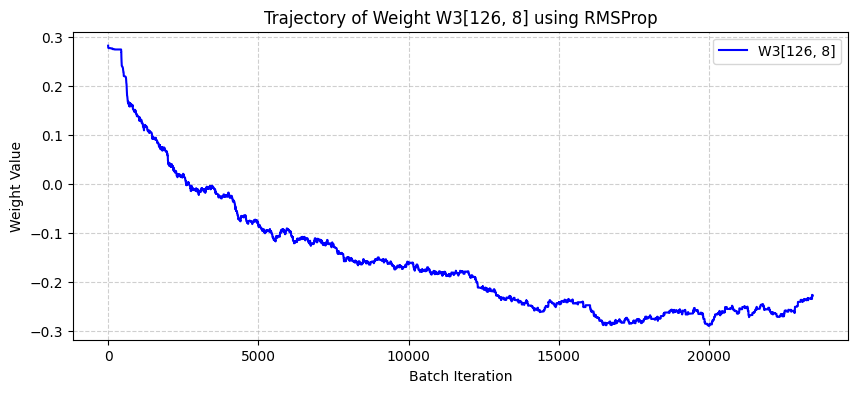

In [217]:
row, col = 126, 8
weight_trajectory = [w[row, col] for w in W3_list]

plt.figure(figsize=(10, 4))
plt.plot(weight_trajectory, color='blue', linewidth=1.5, label=f'W3[{row}, {col}]')

plt.title(f'Trajectory of Weight W3[{row}, {col}] using RMSProp')
plt.xlabel('Batch Iteration')
plt.ylabel('Weight Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

It is visible from the chart, that the weights are much healthier. There are no spikes and oscillations.

### 4. Adam

Adam unifies the optimizers above. Adam = Momentum + Nesterov or RMSProp. Where each earlier optimizer solved only half of the optimization puzzle, Adam combines their best ideas into a single algorithm.

In [218]:
epochs = 50
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
output_layer_neurons = 10

learning_rate = 0.001  
beta1 = 0.9            # momentum
beta2 = 0.999           # rmsprop
epsilon = 1e-8         # rmsprop

np.random.seed(11)

W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1])
b1 = np.zeros((1, number_of_neurons))

W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons)
b2 = np.zeros((1, number_of_neurons))

W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons)
b3 = np.zeros((1, output_layer_neurons))

# Step Counter
t = 0

# Moment Buffers 
m_W1, m_b1 = np.zeros_like(W1), np.zeros_like(b1)
m_W2, m_b2 = np.zeros_like(W2), np.zeros_like(b2)
m_W3, m_b3 = np.zeros_like(W3), np.zeros_like(b3)

# RMSProp Buffers
s_W1, s_b1 = np.zeros_like(W1), np.zeros_like(b1)
s_W2, s_b2 = np.zeros_like(W2), np.zeros_like(b2)
s_W3, s_b3 = np.zeros_like(W3), np.zeros_like(b3)

def relu_derivative(z):
    return (z > 0).astype(float)

history_loss = []
history_acc = []
W3_list = []

print("Starting training...\n" + "-" * 45)


for epoch in range(epochs):
    
    # SHUFFLE DATA AT START OF EPOCH
    indices = np.arange(num_sample)
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_losses = []
    epoch_accuracies = []

    # MINI-BATCH LOOP
    for i in range(0, num_sample, batch_size):
        t += 1  

        X_batch = X_shuffled[i : i + batch_size]
        Y_batch = Y_shuffled[i : i + batch_size]
        m = X_batch.shape[0]

        # --- FORWARD PASS ---
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        Z2 = A1 @ W2 + b2
        A2 = relu(Z2)

        Z3 = A2 @ W3 + b3
        A3 = softmax(Z3)

        # LOSS & ACCURACY
        loss = categorical_cross_entropy(Y_batch, A3)
        preds = A3.argmax(axis=1)
        targets = Y_batch.argmax(axis=1)
        acc = np.mean(preds == targets)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)

        # BACKPROPAGATION
        dZ3 = (A3 - Y_batch) / m
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
        dW1 = X_batch.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # ADAM STEPPING UPDATES
        # Layer 3
        m_W3 = beta1 * m_W3 + (1 - beta1) * dW3        # from momentum
        s_W3 = beta2 * s_W3 + (1 - beta2) * (dW3 ** 2) # from rmsprop
        m_W3_corrected = m_W3 / (1 - beta1 ** t) # bias correction
        s_W3_corrected = s_W3 / (1 - beta2 ** t) # bias correction
        W3 -= learning_rate * m_W3_corrected / (np.sqrt(s_W3_corrected) + epsilon)
        W3_list.append(W3.copy())

        m_b3 = beta1 * m_b3 + (1 - beta1) * db3         #from momentum
        s_b3 = beta2 * s_b3 + (1 - beta2) * (db3 ** 2)  # from rmsprop
        m_b3_corrected = m_b3 / (1 - beta1 ** t)        # bias correction
        s_b3_corrected = s_b3 / (1 - beta2 ** t)        # bias correction
        b3 -= learning_rate * m_b3_corrected / (np.sqrt(s_b3_corrected) + epsilon)

        # Layer 2
        m_W2 = beta1 * m_W2 + (1 - beta1) * dW2
        s_W2 = beta2 * s_W2 + (1 - beta2) * (dW2 ** 2)
        m_W2_corrected = m_W2 / (1 - beta1 ** t)
        s_W2_corrected = s_W2 / (1 - beta2 ** t)
        W2 -= learning_rate * m_W2_corrected / (np.sqrt(s_W2_corrected) + epsilon)

        m_b2 = beta1 * m_b2 + (1 - beta1) * db2
        s_b2 = beta2 * s_b2 + (1 - beta2) * (db2 ** 2)
        m_b2_corrected = m_b2 / (1 - beta1 ** t)
        s_b2_corrected = s_b2 / (1 - beta2 ** t)
        b2 -= learning_rate * m_b2_corrected / (np.sqrt(s_b2_corrected) + epsilon)

        # Layer 1
        m_W1 = beta1 * m_W1 + (1 - beta1) * dW1
        s_W1 = beta2 * s_W1 + (1 - beta2) * (dW1 ** 2)
        m_W1_corrected = m_W1 / (1 - beta1 ** t)
        s_W1_corrected = s_W1 / (1 - beta2 ** t)
        W1 -= learning_rate * m_W1_corrected / (np.sqrt(s_W1_corrected) + epsilon)

        m_b1 = beta1 * m_b1 + (1 - beta1) * db1
        s_b1 = beta2 * s_b1 + (1 - beta2) * (db1 ** 2)
        m_b1_corrected = m_b1 / (1 - beta1 ** t)
        s_b1_corrected = s_b1 / (1 - beta2 ** t)
        b1 -= learning_rate * m_b1_corrected / (np.sqrt(s_b1_corrected) + epsilon)

    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accuracies)) * 100

    history_loss.append(mean_loss)
    history_acc.append(mean_acc)

    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {mean_loss:.4f} - Accuracy: {mean_acc:.2f}%")

Starting training...
---------------------------------------------


Epoch  1/50 - Loss: 0.3038 - Accuracy: 91.30%
Epoch  2/50 - Loss: 0.1234 - Accuracy: 96.31%
Epoch  3/50 - Loss: 0.0847 - Accuracy: 97.48%
Epoch  4/50 - Loss: 0.0645 - Accuracy: 97.99%
Epoch  5/50 - Loss: 0.0494 - Accuracy: 98.47%
Epoch  6/50 - Loss: 0.0407 - Accuracy: 98.71%
Epoch  7/50 - Loss: 0.0334 - Accuracy: 98.98%
Epoch  8/50 - Loss: 0.0258 - Accuracy: 99.24%
Epoch  9/50 - Loss: 0.0229 - Accuracy: 99.26%
Epoch 10/50 - Loss: 0.0187 - Accuracy: 99.42%
Epoch 11/50 - Loss: 0.0148 - Accuracy: 99.54%
Epoch 12/50 - Loss: 0.0127 - Accuracy: 99.64%
Epoch 13/50 - Loss: 0.0133 - Accuracy: 99.55%
Epoch 14/50 - Loss: 0.0115 - Accuracy: 99.62%
Epoch 15/50 - Loss: 0.0116 - Accuracy: 99.62%
Epoch 16/50 - Loss: 0.0105 - Accuracy: 99.65%
Epoch 17/50 - Loss: 0.0079 - Accuracy: 99.73%
Epoch 18/50 - Loss: 0.0079 - Accuracy: 99.71%
Epoch 19/50 - Loss: 0.0097 - Accuracy: 99.68%
Epoch 20/50 - Loss: 0.0067 - Accuracy: 99.78%
Epoch 21/50 - Loss: 0.0056 - Accuracy: 99.82%
Epoch 22/50 - Loss: 0.0054 - Accur

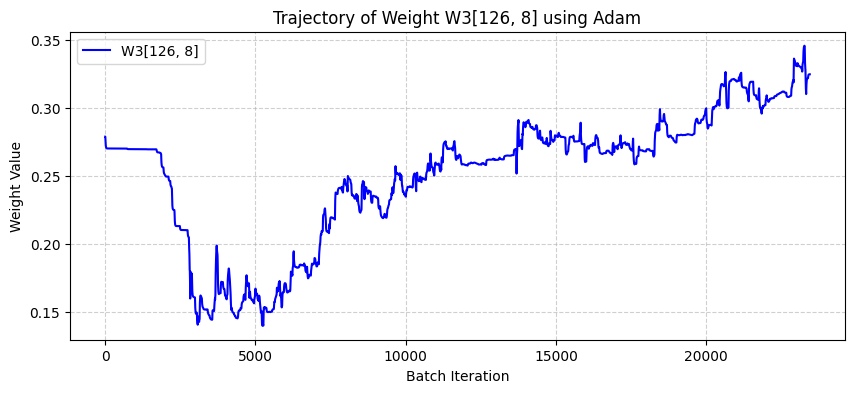

In [219]:
row, col = 126, 8
weight_trajectory = [w[row, col] for w in W3_list]

plt.figure(figsize=(10, 4))
plt.plot(weight_trajectory, color='blue', linewidth=1.5, label=f'W3[{row}, {col}]')

plt.title(f'Trajectory of Weight W3[{row}, {col}] using Adam')
plt.xlabel('Batch Iteration')
plt.ylabel('Weight Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Adding Early Stopping

This will return the best parameter weights. It will cut off traininig when the loss of the validatoin is not decreased by n amount of epochs. Which is set by patience.

In [220]:
validation = pd.read_csv("/Users/homelab/Desktop/deep_learning/mnist_cleaner/archive/mnist_test.csv")
X_val = validation.drop(columns=["label"]).values / 255
raw_y_val = validation["label"].values
Y_val = np.eye(10)[raw_y_val]

This consists of 2 main parts, settings of the early stopping + save weights and the actual if statement.

In [221]:
# settings
patience = 0
patience_counter = 0
best_val_loss = float('inf')

# savebest weights/biases
best_W1, best_b1 = None, None
best_W2, best_b2 = None, None
best_W3, best_b3 = None, None

In [222]:
# 1. HYPERPARAMETERS
epochs = 50
batch_size = 128
patience = 5
num_sample = X.shape[0]
number_of_neurons = 128
output_layer_neurons = 10

learning_rate = 0.001  # RMSProp works best with smaller learning rates
beta = 0.95            # RMSProp decay factor
epsilon = 1e-8         # small number to avoid 0 division

np.random.seed(11)

# 2. INITIALIZE WEIGHTS (He Normal)
W1 = np.random.randn(X.shape[1], number_of_neurons) * np.sqrt(2.0 / X.shape[1])
b1 = np.zeros((1, number_of_neurons))

W2 = np.random.randn(number_of_neurons, number_of_neurons) * np.sqrt(2.0 / number_of_neurons)
b2 = np.zeros((1, number_of_neurons))

W3 = np.random.randn(number_of_neurons, output_layer_neurons) * np.sqrt(2.0 / number_of_neurons)
b3 = np.zeros((1, output_layer_neurons))

# 3. initialize RMSProp accumulators
s_W1 = np.zeros_like(W1)
s_b1 = np.zeros_like(b1)
s_W2 = np.zeros_like(W2)
s_b2 = np.zeros_like(b2)
s_W3 = np.zeros_like(W3)
s_b3 = np.zeros_like(b3)

def relu_derivative(z):
    return (z > 0).astype(float)

history_loss = []
history_acc = []
history_loss_val = []
history_acc_val = []
W3_list = []
patience_counter = 0
best_val_loss = float("inf")

# Best weights and biases
best_W1, best_b1 = None, None
best_W2, best_b2 = None, None
best_W3, best_b3 = None, None
best_epoch = None

print("Starting...\n" + "-"*45)

for epoch in range(epochs):
    
    # SHUFFLE DATA AT START OF EPOCH
    indices = np.arange(num_sample)
    np.random.shuffle(indices)
    X_shuffled = X[indices]
    Y_shuffled = Y[indices]
    
    epoch_losses = []
    epoch_accuracies = []

    # MINI BATCH LOOP
    for i in range(0, num_sample, batch_size):

        X_batch = X_shuffled[i: i + batch_size]
        Y_batch = Y_shuffled[i: i + batch_size]

        # FORWARD PASS 
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)

        Z2 = A1 @ W2 + b2
        A2 = relu(Z2)

        Z3 = A2 @ W3 + b3
        A3 = softmax(Z3)

        # LOSS & ACCURACY
        loss = categorical_cross_entropy(Y_batch, A3)
        preds = A3.argmax(axis=1)
        targets = Y_batch.argmax(axis=1)
        acc = np.mean(preds == targets)

        epoch_losses.append(loss)
        epoch_accuracies.append(acc)

        #### BACKPROPAGATION ####
        # calculating partion derivatives
        
        m = Y_batch.shape[0]

        dZ3 = (A3 - Y_batch) / m
        dW3 = A2.T @ dZ3
        db3 = np.sum(dZ3, axis=0, keepdims=True)

        dZ2 = (dZ3 @ W3.T) * relu_derivative(Z2)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = (dZ2 @ W2.T) * relu_derivative(Z1)
        dW1 = X_batch.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        #### RMSPROP STEPPING UPDATES ####
        # Layer 3
        s_W3 = beta * s_W3 + (1 - beta) * (dW3 ** 2)
        W3 -= learning_rate * dW3 / (np.sqrt(s_W3) + epsilon)
        W3_list.append(W3.copy())

        s_b3 = beta * s_b3 + (1 - beta) * (db3 ** 2)
        b3 -= learning_rate * db3 / (np.sqrt(s_b3)+ epsilon)

        # Layer 2
        s_W2 = beta * s_W2 + (1 - beta) * (dW2 ** 2)
        W2 -= learning_rate * dW2 / (np.sqrt(s_W2) + epsilon)

        s_b2 = beta * s_b2 + (1 - beta) * (db2 ** 2)
        b2 -= learning_rate * db2 / (np.sqrt(s_b2)+ epsilon)

        # Layer 1
        s_W1 = beta * s_W1 + (1 - beta) * (dW1 ** 2)
        W1 -= learning_rate * dW1 / (np.sqrt(s_W1) + epsilon)

        s_b1 = beta * s_b1 + (1 - beta) * (db1 ** 2)
        b1 -= learning_rate * db1 / (np.sqrt(s_b1)+ epsilon)
        
    mean_loss = float(np.mean(epoch_losses))
    mean_acc = float(np.mean(epoch_accuracies)) * 100

    history_loss.append(mean_loss)
    history_acc.append(mean_acc)

    # VALIDATION PART
    Z1_val = X_val @ W1 + b1
    A1_val = relu(Z1_val)

    Z2_val = A1_val @ W2 + b2 
    A2_val = relu(Z2_val)

    Z3_val = A2_val @ W3 + b3
    A3_val = softmax(Z3_val)

    mean_loss_val = categorical_cross_entropy(Y_val, A3_val)
    history_loss_val.append(mean_loss_val)

    preds_val = A3_val.argmax(axis=1)
    targets_val = Y_val.argmax(axis=1)
    acc_val = np.mean(preds_val == targets_val) * 100
    history_acc_val.append(acc_val)


    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {mean_loss:.4f} - Accuracy: {mean_acc:.2f}% - Val Loss: {mean_loss_val:.4f} - Val Accuracy: {acc_val:.2f}%")

    if mean_loss_val < best_val_loss:
        best_val_loss = mean_loss_val
        patience_counter = 0

        best_W1, best_b1 = W1.copy(), b1.copy()
        best_W2, best_b2 = W2.copy(), b2.copy()
        best_W3, best_b3 = W3.copy(), b3.copy()
        best_epoch = epoch

    else:
        patience_counter += 1

        if patience_counter > patience:
            # restore best weights
            W1, b1 = best_W1, best_b1
            W2, b2 = best_W2, best_b2
            W3, b3 = best_W3, best_b3

            print(f"\nEarly stopping triggered at Epoch {epoch}. Weights and biases are restored from Epoch {best_epoch}.")
            break 


Starting...
---------------------------------------------
Epoch  1/50 - Loss: 0.2769 - Accuracy: 91.76% - Val Loss: 0.1420 - Val Accuracy: 95.78%
Epoch  2/50 - Loss: 0.1211 - Accuracy: 96.31% - Val Loss: 0.1012 - Val Accuracy: 96.94%
Epoch  3/50 - Loss: 0.0823 - Accuracy: 97.47% - Val Loss: 0.0949 - Val Accuracy: 97.32%
Epoch  4/50 - Loss: 0.0622 - Accuracy: 98.08% - Val Loss: 0.0767 - Val Accuracy: 97.67%
Epoch  5/50 - Loss: 0.0489 - Accuracy: 98.49% - Val Loss: 0.0767 - Val Accuracy: 97.73%
Epoch  6/50 - Loss: 0.0381 - Accuracy: 98.75% - Val Loss: 0.0810 - Val Accuracy: 97.58%
Epoch  7/50 - Loss: 0.0304 - Accuracy: 99.02% - Val Loss: 0.0819 - Val Accuracy: 97.79%
Epoch  8/50 - Loss: 0.0255 - Accuracy: 99.19% - Val Loss: 0.0880 - Val Accuracy: 97.67%
Epoch  9/50 - Loss: 0.0209 - Accuracy: 99.33% - Val Loss: 0.0800 - Val Accuracy: 97.79%
Epoch 10/50 - Loss: 0.0169 - Accuracy: 99.44% - Val Loss: 0.0901 - Val Accuracy: 97.76%
Epoch 11/50 - Loss: 0.0139 - Accuracy: 99.54% - Val Loss: 0.09

# Curiosity: Train on Keras and Transfer Weights and biases

In [223]:
data = np.load("keras_extracted_weights.npz")

In [224]:
# INITIAL SETTINGS
batch_size = 128
num_sample = X.shape[0]
number_of_neurons = 128
np.random.seed(11)

# 1st hidden layer
W1 = data["W1"]
b1 = data["b1"]

# 2nd hidden layer
W2 = data["W2"]
b2 = data["b2"]

# output layer
output_layer_neurons = 10
W3 = data["W3"]
b3 = data["b3"]

loss_list = []

# derivative of relu
def relu_derivative(z):
    return (z > 0).astype(float)

accuracy = []

for i in range(0, num_sample, batch_size):
    X_batch = X[i: i + batch_size]
    Y_batch = Y[i: i + batch_size]

    # FIRST HIDDEN LAYER
    Z1 = X_batch @ W1 + b1
    A1 = relu(Z1)

    # SECOND HIDDEN LAYER
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    # OUTPUT LAYER
    Z3 = np.dot(A2, W3) + b3
    A3 = softmax(Z3)

    # LOSS FUNCTION
    loss_list.append(categorical_cross_entropy(Y_batch, A3))

    # ACCURACY
    predictions = A3.argmax(axis=1)
    targets = Y_batch.argmax(axis=1)
    accuracy.append(np.mean(predictions == targets))

In [225]:
np.mean(accuracy)

0.9904995113717128

As it is visible, only loading in the weight from the trained model, it achieves a high score.